
# OAKG AAAI 2027: Complete Experiment and Evaluation Notebook

This notebook implements the new experiments requested for the OAKG AAAI 2027 paper:

1. Strong missing-data baselines  
2. Full-annotation partial-observation benchmark  
3. Reference-derived and predicted-segmentation tracks  
4. Ranking-policy ablation  
5. Selective retrieval and risk–coverage analysis  
6. WL graph-kernel and relation-aware graph-encoder interfaces  
7. Observed-region CT and hybrid image–graph interfaces  
8. Cross-backbone observability analysis  
9. Full-to-partial ranking consistency  
10. Structured-query semantic comparisons  
11. Query/candidate diagnostics  
12. Paired bootstrap confidence intervals and Holm correction  

The notebook runs with synthetic demo data by default. Set `USE_DEMO_DATA = False` and provide files following the schemas below to run the actual study.

## Required input files

### `cases.csv`
| column | description |
|---|---|
| `case_id` | unique case identifier |
| `dataset` | source dataset |
| `split` | `train`, `val`, or `test` |
| `available_organs` | pipe-separated organ names available in the complete benchmark |

### `phenotypes_ref.csv` and `phenotypes_pred.csv`
Long-form phenotype records.

| column | description |
|---|---|
| `case_id` | case identifier |
| `feature` | phenotype feature name |
| `value` | numerical or categorical value encoded numerically |
| `feature_type` | `numeric`, `binary`, or `categorical` |
| `support_organs` | pipe-separated anatomical support set; empty for scan-level features |

### `queries.csv`
| column | description |
|---|---|
| `query_id` | query identifier |
| `query_case_id` | source case for case-based retrieval |
| `primary_predicates` | JSON list of predicate dictionaries |
| `secondary_predicates` | JSON list of predicate dictionaries |

Each predicate dictionary uses keys such as:
`{"feature": "liver_tumor_present", "op": "==", "value": 1, "support_organs": ["liver"]}`.

### `relevance.csv`
| column | description |
|---|---|
| `query_id` | query identifier |
| `candidate_id` | candidate case |
| `binary_relevance` | 0/1 reference label fixed before masking |
| `graded_relevance` | graded relevance for nDCG |

### Optional precomputed embeddings
- `ct_observed_embeddings.npz`
- `ct_full_embeddings.npz`
- `compgcn_embeddings_ref.npz`
- `compgcn_embeddings_pred.npz`

Each `.npz` file should contain:
- `case_ids`: string array
- `embeddings`: shape `(n_cases, d)`


In [1]:

from __future__ import annotations

import json
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 2027
rng = np.random.default_rng(SEED)
random.seed(SEED)

ROOT = Path(".")
DATA_DIR = ROOT / "oakg_data"
RESULTS_DIR = ROOT / "oakg_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

USE_DEMO_DATA = True
RUN_WL_BASELINE = True
RUN_NEURAL_BASELINES = False  # Set True after adding real graph/CT data.
N_BOOTSTRAP = 500 if USE_DEMO_DATA else 10_000
TOP_K = 10

ORGANS = ["liver", "pancreas", "spleen", "left_kidney", "right_kidney"]


## 1. Data model and reproducible demo generator

In [2]:

@dataclass(frozen=True)
class ExperimentData:
    cases: pd.DataFrame
    phenotypes_ref: pd.DataFrame
    phenotypes_pred: pd.DataFrame
    queries: pd.DataFrame
    relevance: pd.DataFrame


def _organs_to_text(organs: Iterable[str]) -> str:
    return "|".join(sorted(set(organs)))


def _parse_organs(value: Any) -> frozenset[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return frozenset()
    if isinstance(value, (set, frozenset, list, tuple)):
        return frozenset(map(str, value))
    text = str(value).strip()
    return frozenset(x for x in text.split("|") if x)


def generate_demo_data(n_cases: int = 120) -> ExperimentData:
    """Generate a small but nontrivial benchmark that exercises all notebook code."""
    datasets = np.array(["Pancreas", "LiTS", "FLARE"])
    probs = np.array([0.28, 0.22, 0.50])
    dataset = rng.choice(datasets, size=n_cases, p=probs)
    splits = rng.choice(["train", "val", "test"], size=n_cases, p=[0.55, 0.20, 0.25])
    case_ids = np.array([f"C{i:04d}" for i in range(n_cases)])

    available = []
    for ds in dataset:
        if ds == "Pancreas":
            available.append({"pancreas"})
        elif ds == "LiTS":
            available.append({"liver"})
        else:
            available.append(set(ORGANS))

    cases = pd.DataFrame({
        "case_id": case_ids,
        "dataset": dataset,
        "split": splits,
        "available_organs": [_organs_to_text(x) for x in available],
    })

    feature_specs = [
        ("tumor_burden", "numeric", set()),
        ("lesion_multiplicity", "numeric", set()),
        ("liver_tumor_present", "binary", {"liver"}),
        ("pancreas_tumor_present", "binary", {"pancreas"}),
        ("kidney_tumor_present", "binary", {"left_kidney", "right_kidney"}),
        ("liver_containment", "binary", {"liver"}),
        ("pancreas_containment", "binary", {"pancreas"}),
        ("cross_organ_distribution", "binary", set(ORGANS)),
    ]

    rows_ref, rows_pred = [], []
    latent = {}
    for cid, organs in zip(case_ids, available):
        burden = max(0.0, rng.gamma(2.0, 15.0))
        multiplicity = int(max(1, rng.poisson(1.5)))
        liver = int("liver" in organs and rng.random() < 0.45)
        pancreas = int("pancreas" in organs and rng.random() < 0.35)
        kidney = int(bool({"left_kidney", "right_kidney"} & organs) and rng.random() < 0.18)
        values = {
            "tumor_burden": burden,
            "lesion_multiplicity": multiplicity,
            "liver_tumor_present": liver,
            "pancreas_tumor_present": pancreas,
            "kidney_tumor_present": kidney,
            "liver_containment": int(liver and rng.random() < 0.85),
            "pancreas_containment": int(pancreas and rng.random() < 0.85),
            "cross_organ_distribution": int(sum([liver, pancreas, kidney]) >= 2),
        }
        latent[cid] = values

        for feature, ftype, support in feature_specs:
            value = values[feature]
            rows_ref.append({
                "case_id": cid,
                "feature": feature,
                "value": float(value),
                "feature_type": ftype,
                "support_organs": _organs_to_text(support),
            })

            if ftype == "numeric":
                pred = max(0.0, float(value) + rng.normal(0, 0.08 * max(1.0, float(value))))
            else:
                flip = rng.random() < 0.06
                pred = float(1 - int(value)) if flip else float(value)
            rows_pred.append({
                "case_id": cid,
                "feature": feature,
                "value": pred,
                "feature_type": ftype,
                "support_organs": _organs_to_text(support),
            })

    phen_ref = pd.DataFrame(rows_ref)
    phen_pred = pd.DataFrame(rows_pred)

    test_cases = cases.loc[cases["split"] == "test", "case_id"].tolist()
    if len(test_cases) < 12:
        test_cases = case_ids[-max(12, n_cases // 4):].tolist()

    query_rows, rel_rows = [], []
    query_features = [
        "liver_tumor_present",
        "pancreas_tumor_present",
        "tumor_burden",
        "lesion_multiplicity",
        "cross_organ_distribution",
    ]
    qid = 0
    for qcase in test_cases:
        vals = latent[qcase]
        chosen = rng.choice(query_features, size=2, replace=False).tolist()
        primary = []
        secondary = []
        for idx, feature in enumerate(chosen):
            support = next(s for f, _, s in feature_specs if f == feature)
            if feature == "tumor_burden":
                threshold = float(np.quantile([latent[c]["tumor_burden"] for c in case_ids], 0.55))
                pred = {"feature": feature, "op": ">=", "value": threshold, "support_organs": list(support)}
            elif feature == "lesion_multiplicity":
                pred = {"feature": feature, "op": ">=", "value": 2, "support_organs": list(support)}
            else:
                pred = {"feature": feature, "op": "==", "value": int(vals[feature]), "support_organs": list(support)}
            (primary if idx == 0 else secondary).append(pred)

        query_id = f"Q{qid:04d}"
        qid += 1
        query_rows.append({
            "query_id": query_id,
            "query_case_id": qcase,
            "primary_predicates": json.dumps(primary),
            "secondary_predicates": json.dumps(secondary),
        })

        for cand in case_ids:
            if cand == qcase:
                continue
            cand_vals = latent[cand]

            def holds(p):
                x = cand_vals[p["feature"]]
                if p["op"] == "==":
                    return x == p["value"]
                if p["op"] == ">=":
                    return x >= p["value"]
                if p["op"] == "<=":
                    return x <= p["value"]
                raise ValueError(p["op"])

            p_ok = all(holds(p) for p in primary)
            s_count = sum(holds(p) for p in secondary)
            binary = int(p_ok and s_count == len(secondary))
            if not p_ok:
                grade = 0.0
            elif not secondary:
                grade = 3.0
            else:
                grade = 1.0 + 2.0 * s_count / len(secondary)
            rel_rows.append({
                "query_id": query_id,
                "candidate_id": cand,
                "binary_relevance": binary,
                "graded_relevance": grade,
            })

    return ExperimentData(
        cases=cases,
        phenotypes_ref=phen_ref,
        phenotypes_pred=phen_pred,
        queries=pd.DataFrame(query_rows),
        relevance=pd.DataFrame(rel_rows),
    )


def load_experiment_data(data_dir: Path) -> ExperimentData:
    required = {
        "cases": data_dir / "cases.csv",
        "phenotypes_ref": data_dir / "phenotypes_ref.csv",
        "phenotypes_pred": data_dir / "phenotypes_pred.csv",
        "queries": data_dir / "queries.csv",
        "relevance": data_dir / "relevance.csv",
    }
    missing = [str(path) for path in required.values() if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))
    return ExperimentData(**{name: pd.read_csv(path) for name, path in required.items()})


data = generate_demo_data() if USE_DEMO_DATA else load_experiment_data(DATA_DIR)
display(data.cases.head())
display(data.phenotypes_ref.head())
display(data.queries.head())


,case_id,dataset,split,available_organs
0,C0000,Pancreas,test,pancreas
1,C0001,LiTS,train,liver
2,C0002,Pancreas,test,pancreas
3,C0003,LiTS,val,liver
4,C0004,LiTS,test,liver


,case_id,feature,value,feature_type,support_organs
0,C0000,tumor_burden,4.309436,numeric,
1,C0000,lesion_multiplicity,2.000000,numeric,
2,C0000,liver_tumor_present,0.000000,binary,liver
3,C0000,pancreas_tumor_present,1.000000,binary,pancreas
4,C0000,kidney_tumor_present,0.000000,binary,left_kidney|right_kidney


,query_id,query_case_id,primary_predicates,secondary_predicates
0,Q0000,C0000,"[{""feature"": ""tumor_burden"", ""op"": "">="", ""valu...","[{""feature"": ""pancreas_tumor_present"", ""op"": ""..."
1,Q0001,C0002,"[{""feature"": ""lesion_multiplicity"", ""op"": "">=""...","[{""feature"": ""liver_tumor_present"", ""op"": ""==""..."
2,Q0002,C0004,"[{""feature"": ""liver_tumor_present"", ""op"": ""==""...","[{""feature"": ""lesion_multiplicity"", ""op"": "">=""..."
3,Q0003,C0010,"[{""feature"": ""lesion_multiplicity"", ""op"": "">=""...","[{""feature"": ""pancreas_tumor_present"", ""op"": ""..."
4,Q0004,C0011,"[{""feature"": ""lesion_multiplicity"", ""op"": "">=""...","[{""feature"": ""pancreas_tumor_present"", ""op"": ""..."


## 2. Validation and feature matrices

In [3]:

def validate_data(data: ExperimentData) -> None:
    case_ids = set(data.cases["case_id"])
    for name, frame in {
        "phenotypes_ref": data.phenotypes_ref,
        "phenotypes_pred": data.phenotypes_pred,
    }.items():
        unknown = set(frame["case_id"]) - case_ids
        if unknown:
            raise ValueError(f"{name} contains unknown cases: {sorted(unknown)[:5]}")

    qids = set(data.queries["query_id"])
    if set(data.relevance["query_id"]) - qids:
        raise ValueError("Relevance table contains unknown queries.")
    if set(data.relevance["candidate_id"]) - case_ids:
        raise ValueError("Relevance table contains unknown candidate cases.")
    if data.relevance.duplicated(["query_id", "candidate_id"]).any():
        raise ValueError("Duplicate query/candidate relevance rows detected.")


validate_data(data)


def phenotype_schema(phenotypes: pd.DataFrame) -> pd.DataFrame:
    schema = (
        phenotypes[["feature", "feature_type", "support_organs"]]
        .drop_duplicates()
        .sort_values("feature")
        .reset_index(drop=True)
    )
    if schema["feature"].duplicated().any():
        raise ValueError("A feature has inconsistent type or support metadata.")
    return schema


SCHEMA = phenotype_schema(data.phenotypes_ref)
FEATURES = SCHEMA["feature"].tolist()
FEATURE_INDEX = {f: i for i, f in enumerate(FEATURES)}
FEATURE_SUPPORT = {
    row.feature: _parse_organs(row.support_organs)
    for row in SCHEMA.itertuples(index=False)
}
FEATURE_TYPE = dict(zip(SCHEMA["feature"], SCHEMA["feature_type"]))


def build_feature_matrix(
    cases: pd.DataFrame,
    phenotypes: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    case_order = cases["case_id"].tolist()
    pivot = phenotypes.pivot(index="case_id", columns="feature", values="value")
    pivot = pivot.reindex(index=case_order, columns=FEATURES)
    X = pivot.to_numpy(dtype=float)
    M = ~np.isnan(X)
    return X, M, case_order


X_REF_FULL, M_REF_FULL, CASE_ORDER = build_feature_matrix(data.cases, data.phenotypes_ref)
X_PRED_FULL, M_PRED_FULL, _ = build_feature_matrix(data.cases, data.phenotypes_pred)
CASE_TO_ROW = {c: i for i, c in enumerate(CASE_ORDER)}

with np.errstate(all="ignore"):
    FEATURE_RANGES = np.nanmax(X_REF_FULL, axis=0) - np.nanmin(X_REF_FULL, axis=0)
FEATURE_RANGES = np.where(
    (~np.isfinite(FEATURE_RANGES)) | (FEATURE_RANGES == 0),
    1.0,
    FEATURE_RANGES,
)

print("Feature matrix:", X_REF_FULL.shape)
display(SCHEMA)


Feature matrix: (120, 8)


,feature,feature_type,support_organs
0,cross_organ_distribution,binary,left_kidney|liver|pancreas|right_kidney|spleen
1,kidney_tumor_present,binary,left_kidney|right_kidney
2,lesion_multiplicity,numeric,
3,liver_containment,binary,liver
4,liver_tumor_present,binary,liver
5,pancreas_containment,binary,pancreas
6,pancreas_tumor_present,binary,pancreas
7,tumor_burden,numeric,


## 3. Observation masks and masking regimes

In [4]:

@dataclass(frozen=True)
class MaskingRealization:
    name: str
    seed: int
    observation_sets: dict[str, frozenset[str]]
    metadata: dict[str, Any]


def make_uniform_mask(
    cases: pd.DataFrame,
    retained_organs: Sequence[str],
    seed: int = SEED,
) -> MaskingRealization:
    retained = frozenset(retained_organs)
    obs = {
        row.case_id: _parse_organs(row.available_organs) & retained
        for row in cases.itertuples(index=False)
    }
    return MaskingRealization("uniform", seed, obs, {"retained_organs": sorted(retained)})


def make_random_mask(
    cases: pd.DataFrame,
    missing_fraction: float,
    seed: int,
) -> MaskingRealization:
    local_rng = np.random.default_rng(seed)
    obs = {}
    for row in cases.itertuples(index=False):
        available = sorted(_parse_organs(row.available_organs))
        if not available:
            obs[row.case_id] = frozenset()
            continue
        keep_n = max(1, int(round(len(available) * (1.0 - missing_fraction))))
        kept = local_rng.choice(available, size=min(keep_n, len(available)), replace=False)
        obs[row.case_id] = frozenset(map(str, kept))
    return MaskingRealization(
        "random",
        seed,
        obs,
        {"missing_fraction": float(missing_fraction)},
    )


def make_dataset_style_mask(
    cases: pd.DataFrame,
    style: str,
    seed: int = SEED,
) -> MaskingRealization:
    styles = {
        "pancreas_only": {"pancreas"},
        "liver_only": {"liver"},
        "kidney_only": {"left_kidney", "right_kidney"},
        "multi_organ": set(ORGANS),
    }
    if style not in styles:
        raise ValueError(f"Unknown style: {style}")
    target = styles[style]
    obs = {
        row.case_id: _parse_organs(row.available_organs) & target
        for row in cases.itertuples(index=False)
    }
    return MaskingRealization("dataset_style", seed, obs, {"style": style})


def make_asymmetric_mask(
    cases: pd.DataFrame,
    query_case_ids: set[str],
    direction: str,
    seed: int = SEED,
) -> MaskingRealization:
    if direction not in {"broad_to_narrow", "narrow_to_broad"}:
        raise ValueError(direction)
    broad = set(ORGANS)
    narrow = {"liver"}  # Change or sample narrow styles in the actual study.
    obs = {}
    for row in cases.itertuples(index=False):
        available = _parse_organs(row.available_organs)
        is_query = row.case_id in query_case_ids
        target = broad if (is_query == (direction == "broad_to_narrow")) else narrow
        obs[row.case_id] = available & target
    return MaskingRealization("asymmetric", seed, obs, {"direction": direction})


def feature_mask_from_observation_sets(
    observation_sets: Mapping[str, frozenset[str]],
    case_order: Sequence[str],
) -> np.ndarray:
    mask = np.zeros((len(case_order), len(FEATURES)), dtype=bool)
    for i, cid in enumerate(case_order):
        observed = observation_sets[cid]
        for j, feature in enumerate(FEATURES):
            support = FEATURE_SUPPORT[feature]
            mask[i, j] = support.issubset(observed)
    return mask


def apply_mask(
    X_full: np.ndarray,
    base_available: np.ndarray,
    realization: MaskingRealization,
) -> tuple[np.ndarray, np.ndarray]:
    support_mask = feature_mask_from_observation_sets(realization.observation_sets, CASE_ORDER)
    observed = base_available & support_mask
    X = X_full.copy()
    X[~observed] = np.nan
    return X, observed


QUERY_CASE_IDS = set(data.queries["query_case_id"])
MASKING_REALIZATIONS = [
    make_uniform_mask(data.cases, ORGANS),
    *[
        make_random_mask(data.cases, frac, seed=SEED + i)
        for i, frac in enumerate([0.20, 0.40, 0.60, 0.80], start=1)
    ],
    *[
        make_dataset_style_mask(data.cases, style)
        for style in ["pancreas_only", "liver_only", "kidney_only", "multi_organ"]
    ],
    make_asymmetric_mask(data.cases, QUERY_CASE_IDS, "broad_to_narrow"),
    make_asymmetric_mask(data.cases, QUERY_CASE_IDS, "narrow_to_broad"),
]

[(m.name, m.metadata) for m in MASKING_REALIZATIONS]


[('uniform',
  {'retained_organs': ['left_kidney',
    'liver',
    'pancreas',
    'right_kidney',
    'spleen']}),
 ('random', {'missing_fraction': 0.2}),
 ('random', {'missing_fraction': 0.4}),
 ('random', {'missing_fraction': 0.6}),
 ('random', {'missing_fraction': 0.8}),
 ('dataset_style', {'style': 'pancreas_only'}),
 ('dataset_style', {'style': 'liver_only'}),
 ('dataset_style', {'style': 'kidney_only'}),
 ('dataset_style', {'style': 'multi_organ'}),
 ('asymmetric', {'direction': 'broad_to_narrow'}),
 ('asymmetric', {'direction': 'narrow_to_broad'})]

## 4. Retrieval metrics and ranking utilities

In [5]:

def precision_at_k(y: np.ndarray, scores: np.ndarray, k: int = TOP_K) -> float:
    if len(y) == 0:
        return np.nan
    order = np.argsort(-scores, kind="mergesort")[:k]
    return float(np.mean(y[order] > 0))


def recall_at_k(y: np.ndarray, scores: np.ndarray, k: int = TOP_K) -> float:
    positives = int(np.sum(y > 0))
    if positives == 0:
        return np.nan
    order = np.argsort(-scores, kind="mergesort")[:k]
    return float(np.sum(y[order] > 0) / positives)


def average_precision(y: np.ndarray, scores: np.ndarray) -> float:
    if np.sum(y > 0) == 0:
        return np.nan
    return float(average_precision_score((y > 0).astype(int), scores))


def ndcg_at_k(grades: np.ndarray, scores: np.ndarray, k: int = TOP_K) -> float:
    if len(grades) == 0:
        return np.nan
    order = np.argsort(-scores, kind="mergesort")[:k]
    gains = np.power(2.0, grades[order]) - 1.0
    discounts = np.log2(np.arange(2, len(order) + 2))
    dcg = float(np.sum(gains / discounts))

    ideal = np.argsort(-grades, kind="mergesort")[:k]
    ideal_gains = np.power(2.0, grades[ideal]) - 1.0
    idcg = float(np.sum(ideal_gains / np.log2(np.arange(2, len(ideal) + 2))))
    return dcg / idcg if idcg > 0 else np.nan


def query_metric_row(
    query_id: str,
    method: str,
    candidate_ids: Sequence[str],
    scores: np.ndarray,
    relevance: pd.DataFrame,
    served: bool = True,
) -> dict[str, Any]:
    rel = relevance.loc[relevance["query_id"] == query_id].set_index("candidate_id")
    binary = rel.reindex(candidate_ids)["binary_relevance"].fillna(0).to_numpy(dtype=float)
    graded = rel.reindex(candidate_ids)["graded_relevance"].fillna(0).to_numpy(dtype=float)

    if not served or len(scores) == 0:
        return {
            "query_id": query_id,
            "method": method,
            "P@10": np.nan,
            "R@10": np.nan,
            "AP": np.nan,
            "nDCG@10": np.nan,
            "served": False,
        }

    return {
        "query_id": query_id,
        "method": method,
        "P@10": precision_at_k(binary, scores),
        "R@10": recall_at_k(binary, scores),
        "AP": average_precision(binary, scores),
        "nDCG@10": ndcg_at_k(graded, scores),
        "served": True,
    }


def aggregate_metrics(query_results: pd.DataFrame) -> pd.DataFrame:
    metrics = ["P@10", "R@10", "AP", "nDCG@10"]
    summary = (
        query_results.groupby("method")[metrics]
        .mean()
        .rename(columns={"AP": "mAP"})
    )
    served = query_results.groupby("method")["served"].mean().rename("ServedRate")
    return summary.join(served).reset_index()


## 5. Strong phenotype-vector baselines

In [6]:

def fit_imputation_statistics(
    X: np.ndarray,
    M: np.ndarray,
    train_rows: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    train = X[train_rows]
    train_m = M[train_rows]
    means = np.zeros(X.shape[1], dtype=float)
    modes = np.zeros(X.shape[1], dtype=float)
    for j, feature in enumerate(FEATURES):
        vals = train[train_m[:, j], j]
        means[j] = np.mean(vals) if len(vals) else 0.0
        if len(vals):
            unique, counts = np.unique(vals, return_counts=True)
            modes[j] = unique[np.argmax(counts)]
        else:
            modes[j] = 0.0
    return means, modes


TRAIN_ROWS = data.cases["split"].eq("train").to_numpy()
FEATURE_MEANS, FEATURE_MODES = fit_imputation_statistics(
    X_REF_FULL, M_REF_FULL, TRAIN_ROWS
)


def cosine_pair(xq: np.ndarray, xj: np.ndarray) -> float:
    nq = np.linalg.norm(xq)
    nj = np.linalg.norm(xj)
    if nq == 0 or nj == 0:
        return 0.0
    return float(np.dot(xq, xj) / (nq * nj))


def zero_imputed_similarity(
    q_idx: int, cand_idx: np.ndarray, X: np.ndarray, M: np.ndarray
) -> np.ndarray:
    xq = np.nan_to_num(X[q_idx], nan=0.0)
    xc = np.nan_to_num(X[cand_idx], nan=0.0)
    return cosine_similarity(xq[None, :], xc)[0]


def mean_imputed_similarity(
    q_idx: int, cand_idx: np.ndarray, X: np.ndarray, M: np.ndarray
) -> np.ndarray:
    fill = np.array([
        FEATURE_MEANS[j] if FEATURE_TYPE[f] == "numeric" else FEATURE_MODES[j]
        for j, f in enumerate(FEATURES)
    ])
    xq = np.where(M[q_idx], X[q_idx], fill)
    xc = np.where(M[cand_idx], X[cand_idx], fill)
    return cosine_similarity(xq[None, :], xc)[0]


def missing_indicator_similarity(
    q_idx: int, cand_idx: np.ndarray, X: np.ndarray, M: np.ndarray
) -> np.ndarray:
    xq = np.nan_to_num(X[q_idx], nan=0.0)
    xc = np.nan_to_num(X[cand_idx], nan=0.0)
    zq = np.concatenate([xq, M[q_idx].astype(float)])
    zc = np.concatenate([xc, M[cand_idx].astype(float)], axis=1)
    return cosine_similarity(zq[None, :], zc)[0]


def masked_cosine_similarity(
    q_idx: int, cand_idx: np.ndarray, X: np.ndarray, M: np.ndarray
) -> np.ndarray:
    scores = np.full(len(cand_idx), np.nan)
    for i, j in enumerate(cand_idx):
        joint = M[q_idx] & M[j]
        if not np.any(joint):
            continue
        scores[i] = cosine_pair(X[q_idx, joint], X[j, joint])
    return scores


def gower_similarity(
    q_idx: int,
    cand_idx: np.ndarray,
    X: np.ndarray,
    M: np.ndarray,
    ranges: np.ndarray | None = None,
) -> np.ndarray:
    if ranges is None:
        with np.errstate(all="ignore"):
            ranges = np.nanmax(X, axis=0) - np.nanmin(X, axis=0)
        ranges = np.where((~np.isfinite(ranges)) | (ranges == 0), 1.0, ranges)

    out = np.full(len(cand_idx), np.nan)
    for i, j in enumerate(cand_idx):
        joint = M[q_idx] & M[j]
        if not np.any(joint):
            continue
        sims = []
        for col in np.flatnonzero(joint):
            if FEATURE_TYPE[FEATURES[col]] == "numeric":
                sims.append(1.0 - min(1.0, abs(X[q_idx, col] - X[j, col]) / ranges[col]))
            else:
                sims.append(float(X[q_idx, col] == X[j, col]))
        out[i] = float(np.mean(sims))
    return out


## 6. OAKG support-restricted similarity and ranking policies

In [7]:

def observation_overlap(
    q_case: str,
    c_case: str,
    realization: MaskingRealization,
) -> tuple[frozenset[str], float]:
    oq = realization.observation_sets[q_case]
    oc = realization.observation_sets[c_case]
    inter = oq & oc
    union = oq | oc
    gamma = len(inter) / len(union) if union else 0.0
    return inter, gamma


def oakg_similarity_components(
    q_idx: int,
    c_idx: int,
    X: np.ndarray,
    M: np.ndarray,
) -> tuple[float | None, dict[str, float]]:
    joint = M[q_idx] & M[c_idx]
    if not np.any(joint):
        return None, {}

    groups = {
        "numeric": np.array([FEATURE_TYPE[f] == "numeric" for f in FEATURES]),
        "set": np.array([FEATURE_TYPE[f] != "numeric" for f in FEATURES]),
    }

    components = {}
    numeric_joint = joint & groups["numeric"]
    if np.any(numeric_joint):
        d = np.abs(X[q_idx, numeric_joint] - X[c_idx, numeric_joint])
        components["numeric"] = float(
            np.mean(np.maximum(0.0, 1.0 - d / FEATURE_RANGES[numeric_joint]))
        )

    set_joint = joint & groups["set"]
    if np.any(set_joint):
        qv = X[q_idx, set_joint]
        cv = X[c_idx, set_joint]
        # Binary/categorical agreement over supported dimensions.
        components["categorical_relational"] = float(np.mean(qv == cv))

    if not components:
        return None, {}
    return float(np.mean(list(components.values()))), components


def rank_policy(
    similarity: float | None,
    gamma: float,
    policy: str,
    gamma_min: float = 0.25,
    evidence_bins: Sequence[float] = (0.25, 0.50, 0.75),
) -> float | tuple[int, float] | None:
    if similarity is None:
        return None
    if policy == "similarity":
        return similarity
    if policy == "product":
        return gamma * similarity
    if policy == "threshold":
        return similarity if gamma >= gamma_min else None
    if policy == "lexicographic":
        category = int(np.digitize(gamma, evidence_bins, right=False))
        return category, similarity
    raise ValueError(policy)


def oakg_scores(
    query_case: str,
    candidate_ids: Sequence[str],
    X: np.ndarray,
    M: np.ndarray,
    realization: MaskingRealization,
    policy: str = "product",
    gamma_min: float = 0.25,
) -> tuple[np.ndarray, np.ndarray]:
    q_idx = CASE_TO_ROW[query_case]
    raw_scores = []
    eligible = []
    for cand in candidate_ids:
        c_idx = CASE_TO_ROW[cand]
        inter, gamma = observation_overlap(query_case, cand, realization)
        if not inter:
            raw_scores.append(np.nan)
            eligible.append(False)
            continue
        s, _ = oakg_similarity_components(q_idx, c_idx, X, M)
        score = rank_policy(s, gamma, policy, gamma_min)
        if score is None:
            raw_scores.append(np.nan)
            eligible.append(False)
        elif isinstance(score, tuple):
            category, sim = score
            raw_scores.append(category * 10.0 + sim)
            eligible.append(True)
        else:
            raw_scores.append(float(score))
            eligible.append(True)
    return np.asarray(raw_scores, dtype=float), np.asarray(eligible, dtype=bool)


## 7. Generic benchmark runner

In [8]:

BASELINE_FUNCTIONS: dict[str, Callable[..., np.ndarray]] = {
    "Zero imputation": zero_imputed_similarity,
    "Mean imputation": mean_imputed_similarity,
    "Missingness indicators": missing_indicator_similarity,
    "Masked cosine": masked_cosine_similarity,
    "Gower": gower_similarity,
}


def candidate_pool(query_case_id: str) -> list[str]:
    # Exclude the query case. Add patient-group exclusions here when required.
    return [c for c in CASE_ORDER if c != query_case_id]


def evaluate_vector_methods(
    X: np.ndarray,
    M: np.ndarray,
    track: str,
    realization: MaskingRealization,
) -> pd.DataFrame:
    rows = []
    for query in data.queries.itertuples(index=False):
        candidates = candidate_pool(query.query_case_id)
        cidx = np.array([CASE_TO_ROW[c] for c in candidates], dtype=int)
        qidx = CASE_TO_ROW[query.query_case_id]

        for method, fn in BASELINE_FUNCTIONS.items():
            scores = fn(qidx, cidx, X, M)
            valid = np.isfinite(scores)
            row = query_metric_row(
                query.query_id,
                f"{method} [{track}]",
                np.asarray(candidates)[valid],
                scores[valid],
                data.relevance,
                served=bool(np.any(valid)),
            )
            row.update({
                "track": track,
                "masking_regime": realization.name,
                "mask_metadata": json.dumps(realization.metadata, sort_keys=True),
            })
            rows.append(row)

        for policy in ["similarity", "product", "threshold", "lexicographic"]:
            scores, eligible = oakg_scores(
                query.query_case_id,
                candidates,
                X,
                M,
                realization,
                policy=policy,
                gamma_min=0.25,
            )
            valid = eligible & np.isfinite(scores)
            row = query_metric_row(
                query.query_id,
                f"OAKG-{policy} [{track}]",
                np.asarray(candidates)[valid],
                scores[valid],
                data.relevance,
                served=bool(np.any(valid)),
            )
            row.update({
                "track": track,
                "masking_regime": realization.name,
                "mask_metadata": json.dumps(realization.metadata, sort_keys=True),
            })
            rows.append(row)
    return pd.DataFrame(rows)


def evaluate_realization(realization: MaskingRealization) -> pd.DataFrame:
    ref_x, ref_m = apply_mask(X_REF_FULL, M_REF_FULL, realization)
    pred_x, pred_m = apply_mask(X_PRED_FULL, M_PRED_FULL, realization)
    return pd.concat([
        evaluate_vector_methods(ref_x, ref_m, "ref", realization),
        evaluate_vector_methods(pred_x, pred_m, "pred", realization),
    ], ignore_index=True)


demo_realization = make_random_mask(data.cases, 0.40, SEED + 44)
demo_results = evaluate_realization(demo_realization)
display(aggregate_metrics(demo_results).sort_values("nDCG@10", ascending=False).head(12))


,method,P@10,R@10,mAP,nDCG@10,ServedRate
7,Missingness indicators [ref],0.394286,0.106803,0.393230,0.421065,1.0
6,Missingness indicators [pred],0.391429,0.107798,0.394767,0.416672,1.0
11,OAKG-product [ref],0.388571,0.179639,0.394912,0.411943,1.0
9,OAKG-lexicographic [ref],0.385714,0.177974,0.388681,0.409306,1.0
8,OAKG-lexicographic [pred],0.377143,0.173047,0.389773,0.402615,1.0
1,Gower [ref],0.365714,0.107782,0.381997,0.400066,1.0
10,OAKG-product [pred],0.371429,0.170830,0.393910,0.399388,1.0
5,Mean imputation [ref],0.354286,0.097354,0.388682,0.392144,1.0
17,Zero imputation [ref],0.354286,0.097354,0.388682,0.392144,1.0
12,OAKG-similarity [pred],0.348571,0.163776,0.409409,0.381853,1.0


## 8. Full benchmark across masking regimes

In [9]:

# This is the main experiment loop. On the real 598-case FLARE benchmark,
# consider parallelizing by realization or query.
all_results = []
for realization in MASKING_REALIZATIONS:
    all_results.append(evaluate_realization(realization))

RESULTS = pd.concat(all_results, ignore_index=True)
RESULTS.to_csv(RESULTS_DIR / "query_level_retrieval_results.csv", index=False)

SUMMARY = (
    RESULTS.groupby(["track", "masking_regime", "mask_metadata", "method"])
    [["P@10", "R@10", "AP", "nDCG@10", "served"]]
    .mean()
    .reset_index()
    .rename(columns={"AP": "mAP", "served": "ServedRate"})
)
SUMMARY.to_csv(RESULTS_DIR / "retrieval_summary.csv", index=False)

display(SUMMARY.head(20))


,track,masking_regime,mask_metadata,method,P@10,R@10,mAP,nDCG@10,ServedRate
0,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",Gower [pred],0.362857,0.098687,0.377972,0.395816,1.000000
1,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",Masked cosine [pred],0.280000,0.070901,0.346374,0.303838,1.000000
2,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",Mean imputation [pred],0.360000,0.103052,0.384743,0.386620,1.000000
3,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",Missingness indicators [pred],0.362857,0.100256,0.393715,0.394133,1.000000
4,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-lexicographic [pred],0.325714,0.240057,0.399093,0.401992,1.000000
5,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-product [pred],0.325714,0.240057,0.399076,0.401992,1.000000
6,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-similarity [pred],0.325714,0.232903,0.428118,0.389869,1.000000
7,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-threshold [pred],0.325714,0.711146,0.503686,0.609080,1.000000
8,pred,asymmetric,"{""direction"": ""broad_to_narrow""}",Zero imputation [pred],0.360000,0.103052,0.384743,0.386620,1.000000
9,pred,asymmetric,"{""direction"": ""narrow_to_broad""}",Gower [pred],0.354286,0.094504,0.371472,0.382400,1.000000


## 9. Reference-to-predicted upstream degradation

In [10]:

def upstream_degradation(summary: pd.DataFrame) -> pd.DataFrame:
    tmp = summary.copy()
    tmp["method_base"] = tmp["method"].str.replace(r" \[(ref|pred)\]$", "", regex=True)
    pivot = tmp.pivot_table(
        index=["masking_regime", "mask_metadata", "method_base"],
        columns="track",
        values=["P@10", "R@10", "mAP", "nDCG@10", "ServedRate"],
    )
    rows = []
    for idx, row in pivot.iterrows():
        result = {
            "masking_regime": idx[0],
            "mask_metadata": idx[1],
            "method": idx[2],
        }
        for metric in ["P@10", "R@10", "mAP", "nDCG@10", "ServedRate"]:
            if (metric, "ref") in row.index and (metric, "pred") in row.index:
                result[f"Delta_upstream_{metric}"] = row[(metric, "ref")] - row[(metric, "pred")]
        rows.append(result)
    return pd.DataFrame(rows)


UPSTREAM = upstream_degradation(SUMMARY)
UPSTREAM.to_csv(RESULTS_DIR / "upstream_degradation.csv", index=False)
display(UPSTREAM.head(15))


,masking_regime,mask_metadata,method,Delta_upstream_P@10,Delta_upstream_R@10,Delta_upstream_mAP,Delta_upstream_nDCG@10,Delta_upstream_ServedRate
0,asymmetric,"{""direction"": ""broad_to_narrow""}",Gower,0.011429,0.010135,0.016126,0.016554,0.0
1,asymmetric,"{""direction"": ""broad_to_narrow""}",Masked cosine,0.034286,0.014854,0.009134,0.041038,0.0
2,asymmetric,"{""direction"": ""broad_to_narrow""}",Mean imputation,0.022857,0.009128,0.017742,0.040023,0.0
3,asymmetric,"{""direction"": ""broad_to_narrow""}",Missingness indicators,0.017143,0.006388,0.007074,0.023302,0.0
4,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-lexicographic,-0.005714,-0.005119,0.010976,0.009328,0.0
5,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-product,-0.005714,-0.005119,0.010965,0.009328,0.0
6,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-similarity,0.020000,0.013771,0.019823,0.028610,0.0
7,asymmetric,"{""direction"": ""broad_to_narrow""}",OAKG-threshold,-0.005714,-0.020140,0.034274,0.017368,0.0
8,asymmetric,"{""direction"": ""broad_to_narrow""}",Zero imputation,0.022857,0.009128,0.017742,0.040023,0.0
9,asymmetric,"{""direction"": ""narrow_to_broad""}",Gower,0.028571,0.016834,0.015680,0.027179,0.0


## 10. Paired bootstrap confidence intervals and Holm correction

In [11]:

def paired_bootstrap_difference(
    query_level: pd.DataFrame,
    method_a: str,
    method_b: str,
    metric: str = "nDCG@10",
    n_bootstrap: int = N_BOOTSTRAP,
    seed: int = SEED,
) -> dict[str, float]:
    pivot = query_level.pivot_table(index="query_id", columns="method", values=metric)
    pair = pivot[[method_a, method_b]].dropna()
    if len(pair) == 0:
        return {"n": 0, "difference": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p": np.nan}

    diffs = (pair[method_a] - pair[method_b]).to_numpy()
    local_rng = np.random.default_rng(seed)
    boot = np.empty(n_bootstrap, dtype=float)
    for i in range(n_bootstrap):
        sample = local_rng.choice(diffs, size=len(diffs), replace=True)
        boot[i] = np.mean(sample)

    estimate = float(np.mean(diffs))
    ci_low, ci_high = np.quantile(boot, [0.025, 0.975])
    p = 2.0 * min(np.mean(boot <= 0), np.mean(boot >= 0))
    return {
        "n": len(diffs),
        "difference": estimate,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "p": float(min(1.0, p)),
    }


def comparison_family(
    query_level: pd.DataFrame,
    target_method: str,
    baselines: Sequence[str],
    metric: str = "nDCG@10",
) -> pd.DataFrame:
    rows = []
    for baseline in baselines:
        result = paired_bootstrap_difference(
            query_level, target_method, baseline, metric=metric
        )
        result.update({"target": target_method, "baseline": baseline, "metric": metric})
        rows.append(result)
    out = pd.DataFrame(rows)
    valid = out["p"].notna()
    if valid.any():
        out.loc[valid, "p_holm"] = multipletests(
            out.loc[valid, "p"], method="holm"
        )[1]
    return out


subset = RESULTS[
    (RESULTS["track"] == "ref")
    & (RESULTS["masking_regime"] == "random")
    & (RESULTS["mask_metadata"].str.contains("0.4"))
]
target = "OAKG-product [ref]"
baselines = [
    "Masked cosine [ref]",
    "Missingness indicators [ref]",
    "Gower [ref]",
]
BOOTSTRAP_EXAMPLE = comparison_family(subset, target, baselines)
display(BOOTSTRAP_EXAMPLE)


,n,difference,ci_low,ci_high,p,target,baseline,metric,p_holm
0,35,0.051360,-0.038714,0.142945,0.320,OAKG-product [ref],Masked cosine [ref],nDCG@10,0.96
1,35,0.017983,-0.077742,0.110734,0.716,OAKG-product [ref],Missingness indicators [ref],nDCG@10,1.00
2,35,0.020501,-0.061774,0.105438,0.600,OAKG-product [ref],Gower [ref],nDCG@10,1.00


## 11. Ranking-policy selection on validation data

In [12]:

def choose_policy(
    query_results: pd.DataFrame,
    track: str = "ref",
    metric: str = "nDCG@10",
) -> pd.DataFrame:
    policy_rows = query_results[
        query_results["track"].eq(track)
        & query_results["method"].str.startswith("OAKG-")
    ].copy()
    summary = (
        policy_rows.groupby("method")
        .agg(
            mean_metric=(metric, "mean"),
            served_rate=("served", "mean"),
            n_queries=("query_id", "nunique"),
        )
        .reset_index()
        .sort_values(["mean_metric", "served_rate"], ascending=False)
    )
    return summary


POLICY_SELECTION = choose_policy(
    RESULTS[RESULTS["masking_regime"].eq("random")], track="ref"
)
display(POLICY_SELECTION)

SELECTED_POLICY_METHOD = POLICY_SELECTION.iloc[0]["method"]
print("Validation-selected demonstration policy:", SELECTED_POLICY_METHOD)
print("Confirm the final policy using the actual validation partition before test evaluation.")


,method,mean_metric,served_rate,n_queries
1,OAKG-product [ref],0.438402,1.0,35
0,OAKG-lexicographic [ref],0.429056,1.0,35
2,OAKG-similarity [ref],0.414462,1.0,35
3,OAKG-threshold [ref],0.412791,1.0,35


Validation-selected demonstration policy: OAKG-product [ref]
Confirm the final policy using the actual validation partition before test evaluation.


## 12. Selective retrieval and risk–coverage analysis

/tmp/ipykernel_4021/445325987.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out["AURC"] = np.trapz(valid["risk"], valid["coverage"]) if len(valid) > 1 else np.nan


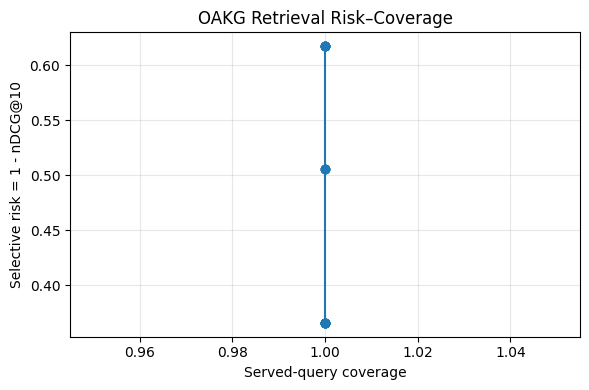

,track,gamma_min,coverage,nDCG@10_served,risk,AURC
0,ref,0.00,1.0,0.382603,0.617397,0.0
1,ref,0.05,1.0,0.382603,0.617397,0.0
2,ref,0.10,1.0,0.382603,0.617397,0.0
3,ref,0.15,1.0,0.382603,0.617397,0.0
4,ref,0.20,1.0,0.382603,0.617397,0.0


In [13]:

def selective_curve(
    X: np.ndarray,
    M: np.ndarray,
    realization: MaskingRealization,
    thresholds: Sequence[float] = np.linspace(0.0, 1.0, 21),
    track: str = "ref",
) -> pd.DataFrame:
    rows = []
    for gamma_min in thresholds:
        query_rows = []
        for query in data.queries.itertuples(index=False):
            candidates = candidate_pool(query.query_case_id)
            scores, eligible = oakg_scores(
                query.query_case_id,
                candidates,
                X,
                M,
                realization,
                policy="threshold",
                gamma_min=float(gamma_min),
            )
            valid = eligible & np.isfinite(scores)
            query_rows.append(
                query_metric_row(
                    query.query_id,
                    f"OAKG-threshold-{gamma_min:.2f}",
                    np.asarray(candidates)[valid],
                    scores[valid],
                    data.relevance,
                    served=bool(np.any(valid)),
                )
            )

        qdf = pd.DataFrame(query_rows)
        served = qdf["served"].mean()
        ndcg = qdf.loc[qdf["served"], "nDCG@10"].mean()
        rows.append({
            "track": track,
            "gamma_min": gamma_min,
            "coverage": served,
            "nDCG@10_served": ndcg,
            "risk": 1.0 - ndcg if np.isfinite(ndcg) else np.nan,
        })
    out = pd.DataFrame(rows).sort_values("coverage")
    valid = out[["coverage", "risk"]].dropna()
    out["AURC"] = np.trapz(valid["risk"], valid["coverage"]) if len(valid) > 1 else np.nan
    return out


curve_realization = make_random_mask(data.cases, 0.60, SEED + 60)
ref_x, ref_m = apply_mask(X_REF_FULL, M_REF_FULL, curve_realization)
RISK_COVERAGE = selective_curve(ref_x, ref_m, curve_realization)
RISK_COVERAGE.to_csv(RESULTS_DIR / "risk_coverage_curve.csv", index=False)

plt.figure(figsize=(6, 4))
plt.plot(RISK_COVERAGE["coverage"], RISK_COVERAGE["risk"], marker="o")
plt.xlabel("Served-query coverage")
plt.ylabel("Selective risk = 1 - nDCG@10")
plt.title("OAKG Retrieval Risk–Coverage")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(RISK_COVERAGE.head())


## 13. Full-to-partial ranking consistency

In [14]:

def top_k_overlap(ids_a: Sequence[str], ids_b: Sequence[str], k: int = TOP_K) -> float:
    return len(set(ids_a[:k]) & set(ids_b[:k])) / k


def rank_ids(candidate_ids: Sequence[str], scores: np.ndarray) -> list[str]:
    valid = np.isfinite(scores)
    ids = np.asarray(candidate_ids)[valid]
    vals = scores[valid]
    order = np.argsort(-vals, kind="mergesort")
    return ids[order].tolist()


def ranking_consistency(
    full_X: np.ndarray,
    full_M: np.ndarray,
    partial_X: np.ndarray,
    partial_M: np.ndarray,
    realization_full: MaskingRealization,
    realization_partial: MaskingRealization,
    track: str,
    policy: str = "product",
) -> pd.DataFrame:
    rows = []
    for query in data.queries.itertuples(index=False):
        candidates = candidate_pool(query.query_case_id)
        full_scores, _ = oakg_scores(
            query.query_case_id, candidates, full_X, full_M, realization_full, policy=policy
        )
        partial_scores, _ = oakg_scores(
            query.query_case_id, candidates, partial_X, partial_M, realization_partial, policy=policy
        )
        full_rank = rank_ids(candidates, full_scores)
        partial_rank = rank_ids(candidates, partial_scores)
        common = [c for c in full_rank if c in set(partial_rank)]
        if len(common) >= 2:
            full_pos = {c: i for i, c in enumerate(full_rank)}
            partial_pos = {c: i for i, c in enumerate(partial_rank)}
            x = [full_pos[c] for c in common]
            y = [partial_pos[c] for c in common]
            tau = kendalltau(x, y).statistic
            rho = spearmanr(x, y).statistic
        else:
            tau = np.nan
            rho = np.nan
        rows.append({
            "query_id": query.query_id,
            "track": track,
            "kendall_tau": tau,
            "spearman_rho": rho,
            "top10_overlap": top_k_overlap(full_rank, partial_rank),
        })
    return pd.DataFrame(rows)


full_realization = make_uniform_mask(data.cases, ORGANS)
partial_realization = make_random_mask(data.cases, 0.60, SEED + 101)

ref_full_x, ref_full_m = apply_mask(X_REF_FULL, M_REF_FULL, full_realization)
ref_part_x, ref_part_m = apply_mask(X_REF_FULL, M_REF_FULL, partial_realization)
pred_full_x, pred_full_m = apply_mask(X_PRED_FULL, M_PRED_FULL, full_realization)
pred_part_x, pred_part_m = apply_mask(X_PRED_FULL, M_PRED_FULL, partial_realization)

CONSISTENCY = pd.concat([
    ranking_consistency(
        ref_full_x, ref_full_m, ref_part_x, ref_part_m,
        full_realization, partial_realization, "ref"
    ),
    ranking_consistency(
        pred_full_x, pred_full_m, pred_part_x, pred_part_m,
        full_realization, partial_realization, "pred"
    ),
], ignore_index=True)

CONSISTENCY.to_csv(RESULTS_DIR / "ranking_consistency.csv", index=False)
display(CONSISTENCY.groupby("track")[["kendall_tau", "spearman_rho", "top10_overlap"]].mean())


,kendall_tau,spearman_rho,top10_overlap
track,,,
pred,0.550493,0.540522,0.625714
ref,0.560321,0.557809,0.605714


## 14. Structured-query semantics: closed world, generic open world, and OAKG

In [15]:

T, F, U = "T", "F", "U"


def predicate_holds(value: float, op: str, target: float) -> bool:
    if op == "==":
        return value == target
    if op == ">=":
        return value >= target
    if op == "<=":
        return value <= target
    if op == ">":
        return value > target
    if op == "<":
        return value < target
    raise ValueError(op)


def evaluate_predicate(
    case_id: str,
    predicate: Mapping[str, Any],
    X: np.ndarray,
    M: np.ndarray,
    semantics: str,
) -> str:
    idx = CASE_TO_ROW[case_id]
    j = FEATURE_INDEX[predicate["feature"]]
    observed = bool(M[idx, j])

    if semantics == "closed_world":
        if not observed:
            return F
    elif semantics in {"open_world", "oakg"}:
        if not observed:
            return U
    else:
        raise ValueError(semantics)

    return T if predicate_holds(X[idx, j], predicate["op"], predicate["value"]) else F


def strong_kleene_and(values: Sequence[str]) -> str:
    if F in values:
        return F
    if all(v == T for v in values):
        return T
    return U


def evaluate_query_on_case(
    case_id: str,
    primary: Sequence[Mapping[str, Any]],
    secondary: Sequence[Mapping[str, Any]],
    X: np.ndarray,
    M: np.ndarray,
    semantics: str,
) -> str:
    vals = [
        evaluate_predicate(case_id, p, X, M, semantics)
        for p in [*primary, *secondary]
    ]
    if semantics == "open_world":
        # Generic open world returns unknown for absent assertions but does not
        # encode benchmark-specific anatomical support beyond feature missingness.
        return strong_kleene_and(vals)
    if semantics == "oakg":
        return strong_kleene_and(vals)
    return T if all(v == T for v in vals) else F


def structured_query_evaluation(
    X: np.ndarray,
    M: np.ndarray,
    track: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for query in data.queries.itertuples(index=False):
        primary = json.loads(query.primary_predicates)
        secondary = json.loads(query.secondary_predicates)
        rel = data.relevance[data.relevance["query_id"].eq(query.query_id)]
        truth_lookup = dict(
            zip(rel["candidate_id"].astype(str), rel["binary_relevance"].astype(int))
        )
        for candidate, binary_truth in truth_lookup.items():
            truth = T if binary_truth else F
            for semantics in ["closed_world", "open_world", "oakg"]:
                prediction = evaluate_query_on_case(
                    candidate, primary, secondary, X, M, semantics
                )
                rows.append({
                    "query_id": query.query_id,
                    "case_id": candidate,
                    "track": track,
                    "semantics": semantics,
                    "truth": truth,
                    "prediction": prediction,
                })
    detail = pd.DataFrame(rows)

    summary_rows = []
    labels = [T, F, U]
    for semantics, group in detail.groupby("semantics"):
        y_true = group["truth"].tolist()
        y_pred = group["prediction"].tolist()
        # Reference truth has T/F; include U in labels to measure unsupported outputs.
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, zero_division=0
        )
        summary_rows.append({
            "track": track,
            "semantics": semantics,
            "precision_T": p[0],
            "recall_T": r[0],
            "f1_T": f[0],
            "precision_F": p[1],
            "recall_F": r[1],
            "f1_F": f[1],
            "precision_U": p[2],
            "recall_U": r[2],
            "f1_U": f[2],
            "macro_F1": np.mean(f),
            "indeterminate_rate": np.mean(group["prediction"].eq(U)),
            "unsupported_negative_rate": np.mean(
                group["prediction"].eq(F) & group["truth"].eq(T)
            ),
        })
    return detail, pd.DataFrame(summary_rows)


sem_realization = make_random_mask(data.cases, 0.60, SEED + 130)
sem_ref_x, sem_ref_m = apply_mask(X_REF_FULL, M_REF_FULL, sem_realization)
QUERY_DETAIL, QUERY_SUMMARY = structured_query_evaluation(sem_ref_x, sem_ref_m, "ref")
QUERY_DETAIL.to_csv(RESULTS_DIR / "structured_query_predictions.csv", index=False)
QUERY_SUMMARY.to_csv(RESULTS_DIR / "structured_query_summary.csv", index=False)

display(QUERY_SUMMARY)


,track,semantics,precision_T,recall_T,f1_T,precision_F,recall_F,f1_F,precision_U,recall_U,f1_U,macro_F1,indeterminate_rate,unsupported_negative_rate
0,ref,closed_world,1.0,0.309859,0.473118,0.780269,1.000000,0.876574,0.0,0.0,0.0,0.449898,0.00000,0.2
1,ref,oakg,1.0,0.309859,0.473118,1.000000,0.822515,0.902615,0.0,0.0,0.0,0.458578,0.32605,0.0
2,ref,open_world,1.0,0.309859,0.473118,1.000000,0.822515,0.902615,0.0,0.0,0.0,0.458578,0.32605,0.0


## 15. Query and candidate-pool diagnostics

In [16]:

def query_diagnostics(data: ExperimentData) -> tuple[pd.DataFrame, pd.DataFrame]:
    query_rows = []
    for query in data.queries.itertuples(index=False):
        primary = json.loads(query.primary_predicates)
        secondary = json.loads(query.secondary_predicates)
        rel = data.relevance[data.relevance["query_id"].eq(query.query_id)]
        n_rel = int(rel["binary_relevance"].sum())
        query_rows.append({
            "query_id": query.query_id,
            "query_case_id": query.query_case_id,
            "primary_features": "|".join(p["feature"] for p in primary),
            "secondary_features": "|".join(p["feature"] for p in secondary),
            "n_primary": len(primary),
            "n_secondary": len(secondary),
            "candidate_pool_size": len(rel),
            "n_relevant": n_rel,
            "relevance_prevalence": n_rel / len(rel) if len(rel) else np.nan,
            "zero_relevant": n_rel == 0,
        })
    query_level = pd.DataFrame(query_rows)

    summary = pd.DataFrame({
        "n_queries": [len(query_level)],
        "mean_candidate_pool": [query_level["candidate_pool_size"].mean()],
        "median_candidate_pool": [query_level["candidate_pool_size"].median()],
        "mean_relevant": [query_level["n_relevant"].mean()],
        "median_relevant": [query_level["n_relevant"].median()],
        "mean_prevalence": [query_level["relevance_prevalence"].mean()],
        "zero_relevant_queries": [query_level["zero_relevant"].sum()],
    })
    return query_level, summary


QUERY_DIAGNOSTICS, QUERY_DIAGNOSTIC_SUMMARY = query_diagnostics(data)
QUERY_DIAGNOSTICS.to_csv(RESULTS_DIR / "query_diagnostics.csv", index=False)
display(QUERY_DIAGNOSTIC_SUMMARY)
display(QUERY_DIAGNOSTICS.head())


,n_queries,mean_candidate_pool,median_candidate_pool,mean_relevant,median_relevant,mean_prevalence,zero_relevant_queries
0,35,119.0,119.0,34.485714,33.0,0.289796,0


,query_id,query_case_id,primary_features,secondary_features,n_primary,n_secondary,candidate_pool_size,n_relevant,relevance_prevalence,zero_relevant
0,Q0000,C0000,tumor_burden,pancreas_tumor_present,1,1,119,18,0.151261,False
1,Q0001,C0002,lesion_multiplicity,liver_tumor_present,1,1,119,33,0.277311,False
2,Q0002,C0004,liver_tumor_present,lesion_multiplicity,1,1,119,33,0.277311,False
3,Q0003,C0010,lesion_multiplicity,pancreas_tumor_present,1,1,119,43,0.361345,False
4,Q0004,C0011,lesion_multiplicity,pancreas_tumor_present,1,1,119,43,0.361345,False


## 16. Weisfeiler–Lehman graph-kernel baseline

In [17]:

def case_graph(case_id: str, X: np.ndarray, M: np.ndarray) -> nx.Graph:
    idx = CASE_TO_ROW[case_id]
    graph = nx.Graph()
    graph.add_node(f"case:{case_id}", label="CTScan")

    for feature, col in FEATURE_INDEX.items():
        if not M[idx, col]:
            continue
        value = X[idx, col]
        support = FEATURE_SUPPORT[feature]
        fnode = f"feature:{feature}:{value:.3f}"
        graph.add_node(fnode, label=f"{feature}={round(float(value), 2)}")
        graph.add_edge(f"case:{case_id}", fnode, relation="hasPhenotype")
        for organ in support:
            onode = f"organ:{organ}"
            graph.add_node(onode, label=f"Organ:{organ}")
            graph.add_edge(fnode, onode, relation="supportedBy")
    return graph


def wl_feature_dict(graph: nx.Graph, h: int = 2) -> dict[str, float]:
    labels = {n: str(graph.nodes[n].get("label", "")) for n in graph.nodes}
    counts: dict[str, float] = {}
    for label in labels.values():
        counts[f"0:{label}"] = counts.get(f"0:{label}", 0.0) + 1.0

    for iteration in range(1, h + 1):
        new_labels = {}
        for node in graph.nodes:
            neighbors = sorted(labels[nbr] for nbr in graph.neighbors(node))
            signature = labels[node] + "||" + "||".join(neighbors)
            new_label = str(hash(signature))
            new_labels[node] = new_label
            key = f"{iteration}:{new_label}"
            counts[key] = counts.get(key, 0.0) + 1.0
        labels = new_labels
    return counts


def wl_embeddings(X: np.ndarray, M: np.ndarray, h: int = 2) -> tuple[np.ndarray, list[str]]:
    feature_dicts = [wl_feature_dict(case_graph(cid, X, M), h=h) for cid in CASE_ORDER]
    vocab = sorted(set().union(*(d.keys() for d in feature_dicts)))
    index = {k: i for i, k in enumerate(vocab)}
    emb = np.zeros((len(CASE_ORDER), len(vocab)), dtype=float)
    for row, d in enumerate(feature_dicts):
        for key, value in d.items():
            emb[row, index[key]] = value
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.where(norms == 0, 1.0, norms)
    return emb, vocab


if RUN_WL_BASELINE:
    wl_realization = make_random_mask(data.cases, 0.40, SEED + 160)
    wl_x, wl_m = apply_mask(X_REF_FULL, M_REF_FULL, wl_realization)
    WL_EMBEDDINGS, WL_VOCAB = wl_embeddings(wl_x, wl_m)
    print("WL embedding shape:", WL_EMBEDDINGS.shape)


WL embedding shape: (120, 1046)



## 17. Relation-aware graph encoder / CompGCN interface

For the paper, use the exact CompGCN implementation selected by UD and record:

- training objective;
- node/relation dimensions;
- number of layers;
- composition operator;
- pooling method;
- optimizer, learning rate, epochs, and weight decay;
- negative sampling;
- validation-selection metric;
- seeds.

The helper below loads precomputed graph embeddings. This keeps retrieval evaluation independent of the training framework. Replace the optional lightweight encoder cell with the official CompGCN implementation used in the paper.


In [18]:

def load_npz_embeddings(path: Path) -> dict[str, np.ndarray]:
    payload = np.load(path, allow_pickle=True)
    ids = payload["case_ids"].astype(str)
    emb = payload["embeddings"].astype(float)
    if emb.ndim != 2 or len(ids) != len(emb):
        raise ValueError(f"Invalid embedding file: {path}")
    return {cid: vector for cid, vector in zip(ids, emb)}


def embedding_scores(
    query_case: str,
    candidate_ids: Sequence[str],
    embeddings: Mapping[str, np.ndarray],
) -> np.ndarray:
    q = embeddings[query_case]
    matrix = np.stack([embeddings[c] for c in candidate_ids])
    return cosine_similarity(q[None, :], matrix)[0]


COMPGCN_REF_PATH = DATA_DIR / "compgcn_embeddings_ref.npz"
COMPGCN_PRED_PATH = DATA_DIR / "compgcn_embeddings_pred.npz"

if COMPGCN_REF_PATH.exists():
    COMPGCN_REF = load_npz_embeddings(COMPGCN_REF_PATH)
    print("Loaded reference-derived CompGCN embeddings:", len(COMPGCN_REF))
else:
    COMPGCN_REF = None
    print("CompGCN reference embeddings not found; interface is ready.")


CompGCN reference embeddings not found; interface is ready.


## 18. Observation-consistent CT embeddings and full-volume upper bound

In [19]:

def restrict_ct_volume(
    volume: np.ndarray,
    observed_region_mask: np.ndarray,
    background_value: float = 0.0,
) -> np.ndarray:
    if volume.shape != observed_region_mask.shape:
        raise ValueError("Volume and observation mask must have the same shape.")
    return np.where(observed_region_mask.astype(bool), volume, background_value)


def masked_global_pool(
    feature_map: np.ndarray,
    pooled_mask: np.ndarray,
) -> np.ndarray:
    """Pool a channel-first feature map (C, D, H, W) over an observed-region mask."""
    if feature_map.ndim != 4:
        raise ValueError("Expected feature map shape (C, D, H, W).")
    if feature_map.shape[1:] != pooled_mask.shape:
        raise ValueError("Feature map spatial shape and mask shape do not match.")
    locations = pooled_mask.astype(bool)
    if not np.any(locations):
        return np.zeros(feature_map.shape[0], dtype=float)
    return feature_map[:, locations].mean(axis=1)


CT_OBS_PATH = DATA_DIR / "ct_observed_embeddings.npz"
CT_FULL_PATH = DATA_DIR / "ct_full_embeddings.npz"

CT_OBS = load_npz_embeddings(CT_OBS_PATH) if CT_OBS_PATH.exists() else None
CT_FULL = load_npz_embeddings(CT_FULL_PATH) if CT_FULL_PATH.exists() else None

print("Observed-region CT embeddings:", "loaded" if CT_OBS else "not found")
print("Full-volume CT upper-bound embeddings:", "loaded" if CT_FULL else "not found")
print(
    "For the actual paper, create CT_OBS using the benchmark reference organ masks "
    "only to define the permitted voxel boundary, then pool features only within that boundary."
)


Observed-region CT embeddings: not found
Full-volume CT upper-bound embeddings: not found
For the actual paper, create CT_OBS using the benchmark reference organ masks only to define the permitted voxel boundary, then pool features only within that boundary.


## 19. Hybrid image–graph retrieval

In [20]:

def zscore_fit(values: np.ndarray) -> tuple[float, float]:
    finite = values[np.isfinite(values)]
    return (
        float(np.mean(finite)) if len(finite) else 0.0,
        float(np.std(finite)) if len(finite) and np.std(finite) > 0 else 1.0,
    )


def zscore_apply(values: np.ndarray, stats: tuple[float, float]) -> np.ndarray:
    mean, std = stats
    return (values - mean) / std


def hybrid_scores(
    graph_scores: np.ndarray,
    image_scores: np.ndarray,
    alpha: float,
    graph_stats: tuple[float, float],
    image_stats: tuple[float, float],
) -> np.ndarray:
    return (
        alpha * zscore_apply(graph_scores, graph_stats)
        + (1.0 - alpha) * zscore_apply(image_scores, image_stats)
    )


def select_hybrid_alpha(
    validation_rows: pd.DataFrame,
    alpha_grid: Sequence[float] = np.linspace(0.0, 1.0, 11),
) -> float:
    """Template: evaluate each alpha on validation queries and select by nDCG@10."""
    required = {"query_id", "candidate_id", "graph_score", "image_score", "graded_relevance"}
    if not required.issubset(validation_rows.columns):
        raise ValueError(f"Validation frame must contain {sorted(required)}")

    gstats = zscore_fit(validation_rows["graph_score"].to_numpy())
    istats = zscore_fit(validation_rows["image_score"].to_numpy())
    rows = []
    for alpha in alpha_grid:
        scores = hybrid_scores(
            validation_rows["graph_score"].to_numpy(),
            validation_rows["image_score"].to_numpy(),
            float(alpha),
            gstats,
            istats,
        )
        frame = validation_rows.assign(hybrid_score=scores)
        query_scores = []
        for _, q in frame.groupby("query_id"):
            query_scores.append(
                ndcg_at_k(q["graded_relevance"].to_numpy(), q["hybrid_score"].to_numpy())
            )
        rows.append((float(alpha), float(np.nanmean(query_scores))))
    return max(rows, key=lambda x: x[1])[0]


## 20. Cross-backbone observability-gain template

In [21]:

def apply_pairwise_observability_filter(
    query_case: str,
    candidate_ids: Sequence[str],
    scores: np.ndarray,
    realization: MaskingRealization,
    gamma_min: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    eligible = np.zeros(len(candidate_ids), dtype=bool)
    adjusted = scores.copy().astype(float)
    for i, cand in enumerate(candidate_ids):
        inter, gamma = observation_overlap(query_case, cand, realization)
        eligible[i] = bool(inter) and gamma >= gamma_min
        if not eligible[i]:
            adjusted[i] = np.nan
    return adjusted, eligible


def cross_backbone_gain(
    query_results: pd.DataFrame,
    base_method: str,
    obs_method: str,
    metric: str = "nDCG@10",
) -> dict[str, float]:
    pivot = query_results.pivot_table(index="query_id", columns="method", values=metric)
    pair = pivot[[base_method, obs_method]].dropna()
    diff = pair[obs_method] - pair[base_method]
    return {
        "backbone": base_method,
        "n_queries": len(pair),
        f"Delta_obs_{metric}": float(diff.mean()) if len(diff) else np.nan,
    }


print(
    "Use apply_pairwise_observability_filter for CT embeddings, and support-restricted "
    "feature/graph construction for phenotype, WL, CompGCN, and hybrid backbones."
)


Use apply_pairwise_observability_filter for CT embeddings, and support-restricted feature/graph construction for phenotype, WL, CompGCN, and hybrid backbones.


## 21. Export publication-ready result tables

In [22]:

def format_metric_ci(mean: float, low: float, high: float, digits: int = 3) -> str:
    if not np.isfinite(mean):
        return "--"
    return f"{mean:.{digits}f} [{low:.{digits}f}, {high:.{digits}f}]"


def bootstrap_metric_ci(
    values: np.ndarray,
    n_bootstrap: int = N_BOOTSTRAP,
    seed: int = SEED,
) -> tuple[float, float, float]:
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    local_rng = np.random.default_rng(seed)
    boot = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        boot[i] = np.mean(local_rng.choice(values, len(values), replace=True))
    return float(values.mean()), *map(float, np.quantile(boot, [0.025, 0.975]))


def publication_table(
    results: pd.DataFrame,
    group_columns: Sequence[str] = ("track", "masking_regime", "method"),
    metrics: Sequence[str] = ("P@10", "R@10", "AP", "nDCG@10"),
) -> pd.DataFrame:
    rows = []
    for keys, group in results.groupby(list(group_columns)):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_columns, keys))
        for metric in metrics:
            mean, low, high = bootstrap_metric_ci(group[metric].to_numpy())
            label = "mAP" if metric == "AP" else metric
            row[label] = format_metric_ci(mean, low, high)
        row["ServedRate"] = float(group["served"].mean())
        rows.append(row)
    return pd.DataFrame(rows)


PUB_TABLE = publication_table(RESULTS)
PUB_TABLE.to_csv(RESULTS_DIR / "publication_ready_retrieval_table.csv", index=False)
display(PUB_TABLE.head(20))


,track,masking_regime,method,P@10,R@10,mAP,nDCG@10,ServedRate
0,pred,asymmetric,Gower [pred],"0.359 [0.266, 0.440]","0.097 [0.074, 0.119]","0.375 [0.320, 0.426]","0.389 [0.303, 0.475]",1.000000
1,pred,asymmetric,Masked cosine [pred],"0.273 [0.199, 0.339]","0.069 [0.052, 0.087]","0.345 [0.296, 0.393]","0.300 [0.226, 0.372]",1.000000
2,pred,asymmetric,Mean imputation [pred],"0.379 [0.290, 0.451]","0.107 [0.083, 0.128]","0.397 [0.341, 0.445]","0.405 [0.323, 0.479]",1.000000
3,pred,asymmetric,Missingness indicators [pred],"0.393 [0.319, 0.460]","0.109 [0.091, 0.126]","0.404 [0.354, 0.452]","0.424 [0.345, 0.491]",1.000000
4,pred,asymmetric,OAKG-lexicographic [pred],"0.337 [0.279, 0.396]","0.211 [0.168, 0.252]","0.384 [0.342, 0.432]","0.396 [0.332, 0.463]",0.814286
5,pred,asymmetric,OAKG-product [pred],"0.337 [0.279, 0.396]","0.211 [0.168, 0.252]","0.384 [0.342, 0.432]","0.396 [0.332, 0.463]",0.814286
6,pred,asymmetric,OAKG-similarity [pred],"0.337 [0.268, 0.422]","0.208 [0.151, 0.272]","0.418 [0.363, 0.488]","0.383 [0.309, 0.470]",0.814286
7,pred,asymmetric,OAKG-threshold [pred],"0.337 [0.279, 0.396]","0.578 [0.482, 0.667]","0.484 [0.425, 0.553]","0.535 [0.462, 0.611]",0.814286
8,pred,asymmetric,Zero imputation [pred],"0.379 [0.290, 0.451]","0.107 [0.083, 0.128]","0.397 [0.341, 0.445]","0.405 [0.323, 0.479]",1.000000
9,pred,dataset_style,Gower [pred],"0.360 [0.302, 0.420]","0.100 [0.084, 0.118]","0.371 [0.336, 0.412]","0.387 [0.330, 0.445]",1.000000



## 22. Final execution checklist for UD

Before generating final paper tables:

- [ ] Replace demo data with the complete FLARE reference-derived benchmark.
- [ ] Generate predicted masks using a frozen, held-out or out-of-fold segmentation model.
- [ ] Confirm that reference masks are used only for fixed relevance labels and controlled image-access boundaries.
- [ ] Run all masking seeds and retain the seed list.
- [ ] Run zero, mean, missing-indicator, masked-cosine, and Gower baselines.
- [ ] Run WL and the exact CompGCN implementation.
- [ ] Generate observed-region CT embeddings and a separately reported full-volume upper bound.
- [ ] Run coverage-blind and observability-aware hybrids with validation-selected \(\alpha\).
- [ ] Select the primary \(S\), \(\gamma S\), threshold, or lexicographic ranking policy on validation data.
- [ ] Rerun the main OAKG test results using the selected policy.
- [ ] Report reference-derived and predicted-segmentation tracks separately.
- [ ] Report paired 95% confidence intervals for OAKG minus masked cosine.
- [ ] Apply Holm correction within each primary comparison family.
- [ ] Export query diagnostics, served-query rates, and zero-relevant-query counts.
- [ ] Verify that full-to-partial ranking comparisons remain within the same input track.
- [ ] Save code version, environment, model checkpoints, preprocessing, and all result CSV files.


In [23]:

print("Result directory:", RESULTS_DIR.resolve())
print("Generated files:")
for path in sorted(RESULTS_DIR.glob("*")):
    print(" -", path.name)


Result directory: /oakg_results
Generated files:
 - publication_ready_retrieval_table.csv
 - query_diagnostics.csv
 - query_level_retrieval_results.csv
 - ranking_consistency.csv
 - retrieval_summary.csv
 - risk_coverage_curve.csv
 - structured_query_predictions.csv
 - structured_query_summary.csv
 - upstream_degradation.csv
